In [305]:
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np

from scipy.interpolate import griddata
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error

In [ ]:
df = pd.read_csv('..\\data\\lola_bathy_age_q_grav_z.csv')
df.head()

,long,lat,FA,age,q_ihfc,q_ps,q_stein,ps_z,stein_z,bathy
0,-129.96667,44.050001,-29.585655,2.095456,39.312845,326.829596,352.314805,3006.649160,4202.691722,-3263.999712
1,-129.96667,44.166668,3.149101,1.699009,38.406696,362.963374,391.266189,2956.211155,3653.620686,-2765.545858
2,-129.96667,44.283334,-27.107563,1.393856,40.291864,400.729854,431.977588,2913.215882,3309.134650,-3027.580954
3,-129.96667,44.400001,-2.101287,1.226661,46.395121,427.167604,460.476876,2887.641615,3149.214842,-2309.992502
4,-129.96667,44.516668,9.750397,0.696184,80.111326,567.020192,611.234757,2792.031822,2776.905527,-2681.019183


note that y = df[['ps_q']] will make the shape (#,#) but y = df['ps_q'] will make the shape (#,)

In [307]:
x = df.drop(columns=['long', 'lat','q_ps', 'q_stein', 'ps_z', 'stein_z', 'FA'])
y = df['FA']

In [308]:
x.head()

,age,q_ihfc,bathy
0,2.095456,39.312845,-3263.999712
1,1.699009,38.406696,-2765.545858
2,1.393856,40.291864,-3027.580954
3,1.226661,46.395121,-2309.992502
4,0.696184,80.111326,-2681.019183


In [309]:
x.shape

(289, 3)

In [310]:
y.head()

0   -29.585655
1     3.149101
2   -27.107563
3    -2.101287
4     9.750397
Name: FA, dtype: float64

In [311]:
ts = 0.2
rs = 17

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=ts, random_state = rs)

this is just for plotting, but ensures that lat/long isnt a dependency

In [312]:
coords_train = df.loc[x_train.index, ['long', 'lat']]
coords_test = df.loc[x_test.index, ['long', 'lat']]

In [313]:
x_train.shape

(231, 3)

this is the raw validation data

In [314]:
x_test.shape

(58, 3)

In [315]:
x_train.describe().round(3)

,age,q_ihfc,bathy
count,231.000,231.000,231.000
mean,2.326,105.019,-2724.200
std,1.053,33.114,217.983
min,0.569,38.407,-3475.639
25%,1.444,85.416,-2829.400
50%,2.165,105.100,-2776.010
75%,3.083,123.405,-2682.698
max,5.257,232.704,-1592.492


In [316]:
x_test.describe().round(3)

,age,q_ihfc,bathy
count,58.000,58.000,58.000
mean,2.310,111.536,-2701.686
std,0.879,32.693,159.424
min,0.869,47.436,-2855.299
25%,1.498,90.248,-2820.124
50%,2.319,107.192,-2761.251
75%,3.024,135.938,-2669.425
max,4.072,186.767,-2138.759


In [317]:
train_data = lgb.Dataset(x_train, label = y_train)
test_data = lgb.Dataset(x_test, label = y_test)

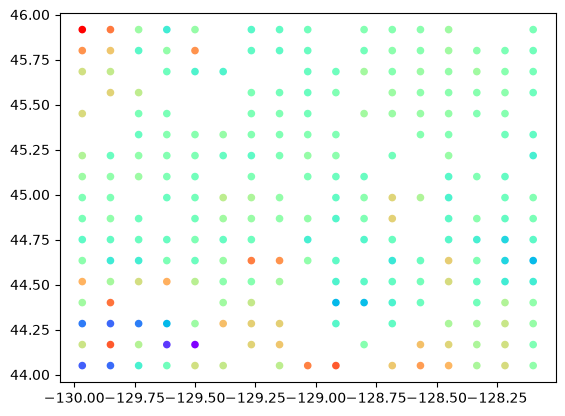

In [318]:
plt.scatter(coords_train['long'], coords_train['lat'], 
            c=y_train, cmap='rainbow', marker='o', s=20)

plt.savefig('..\\figs\\grav\\xval\\aug17_trainpnts.png', dpi=400)
plt.show()

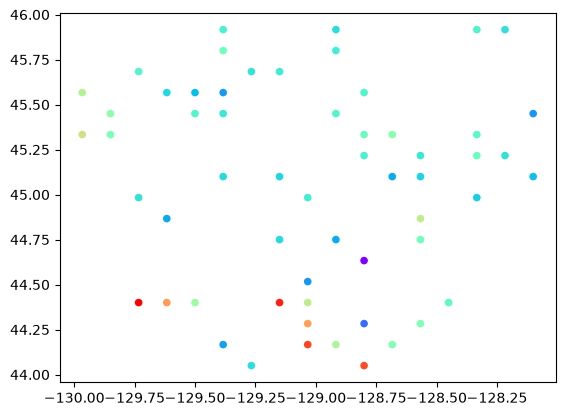

In [319]:
plt.scatter(coords_test['long'], coords_test['lat'], 
            c=y_test, cmap='rainbow', marker='o', s=20)

plt.savefig('..\\figs\\grav\\xval\\aug17_testpnts.png', dpi=400)
plt.show()

'min_data_in_leaf': 20,  # default 20 — lower allows smaller/more specific splits, higher = more conservative

In [320]:
lr = 0.1
nl = 33
mdil = 20

params = {
    'objective':'regression',
    'metric':'rmse',
    'boosting_type':'gbdt',
    'learning_rate':lr,
    'num_leaves':nl,
    'min_data_in_leaf': mdil,
    'verbose':1
}

testing nbr and lr, 500 has R^2 of 0.69 as of aug 14 2:59 pm

nbr is total number of trees build in the model

In [321]:
nbr = 200
model = lgb.train(params, train_data, valid_sets = [test_data], num_boost_round=nbr)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000175 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 234
[LightGBM] [Info] Number of data points in the train set: 231, number of used features: 3
[LightGBM] [Info] Start training from score -4.949974
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

In [322]:
y_pred = model.predict(x_test)

In [323]:
y_pred, y_pred.shape

(array([  6.52489578,   0.0615048 ,  -5.19017549,   8.06718785,
         -8.8748602 ,  -3.02052857,   4.29128285,   0.4302053 ,
          8.15988636,   8.62461067,  -2.94309518,  11.57182439,
         -9.22583739, -11.52817044, -14.09027245, -11.20084004,
         -7.61501963,  -7.42380257,   3.78930197,  -7.53974137,
         -8.05601982,  -8.1200908 ,  -8.27072672, -10.17339518,
        -14.31555082,  -3.49866903,  -9.71473209,  11.43693886,
         -6.81873022,   0.94009115,  -3.0496687 ,   6.50904134,
         -7.15333979,  11.17059263,  -5.90602788,  -5.65392999,
         -8.01801506, -10.79777935,  -5.94202459,  -6.13259847,
         -9.51520956,  -2.21917848,  -6.35735954,  -7.6221728 ,
         -9.38197328,   2.02694403,  -8.33602095,  -7.31071184,
          3.67915064,  -5.3146344 , -17.93622307, -11.19168938,
         -5.82009989,  -3.36394418,  -4.84755212,  -8.03316619,
         -2.49202802,   0.656558  ]),
 (58,))

In [324]:
print(f'RMSE: {root_mean_squared_error(y_test, y_pred)}')
print(f'R^2: {r2_score(y_test, y_pred)}')

RMSE: 4.63845574671793
R^2: 0.6800929060724128


In [325]:
residuals = y_test - y_pred

negative mean: overpredicting

In [326]:
residuals.head(), residuals.describe()

(139   -2.662287
 154    2.566380
 81    -5.553542
 122    9.543625
 125    0.593708
 Name: FA, dtype: float64,
 count    58.000000
 mean      0.112660
 std       4.677587
 min     -13.477445
 25%      -2.411400
 50%      -0.331733
 75%       2.728938
 max      15.037729
 Name: FA, dtype: float64)

In [327]:
# dfr = pd.DataFrame({
#     'long': x_test['long'].values,
#     'lat': x_test['lat'].values,
#     'ps_q_test_data': y_test,
#     'ps_q_predicted': y_pred,
#     'residual': residuals
# })

saving both the csv file and a text file of specified parameters

In [328]:
# pd.DataFrame(dfr).to_csv('..\\created_data\\tests\\xval\\aug17_grav_residuals.csv', index=False)

with open('..\\created_data\\tests\\aug17_grav_params.txt', 'w') as f:
    f.write('saving parameters for this dataset...\n')
    f.write(f'learning rate: {lr}\nnum_boost_rate: {nbr}\ntest size: {ts}\nnum leaves: {nl}\nmin data in leaf: {mdil}\n')
    # f.write(f'gives mean of: {residuals.mean()}')
    f.write(f'\ndescription:\n{residuals.describe()}\n')
    f.write(f'RMSE: {root_mean_squared_error(y_test, y_pred)}')
    f.write(f'R^2: {r2_score(y_test, y_pred)}\n')
    f.write(f'\nnote: this was for random state {rs}')

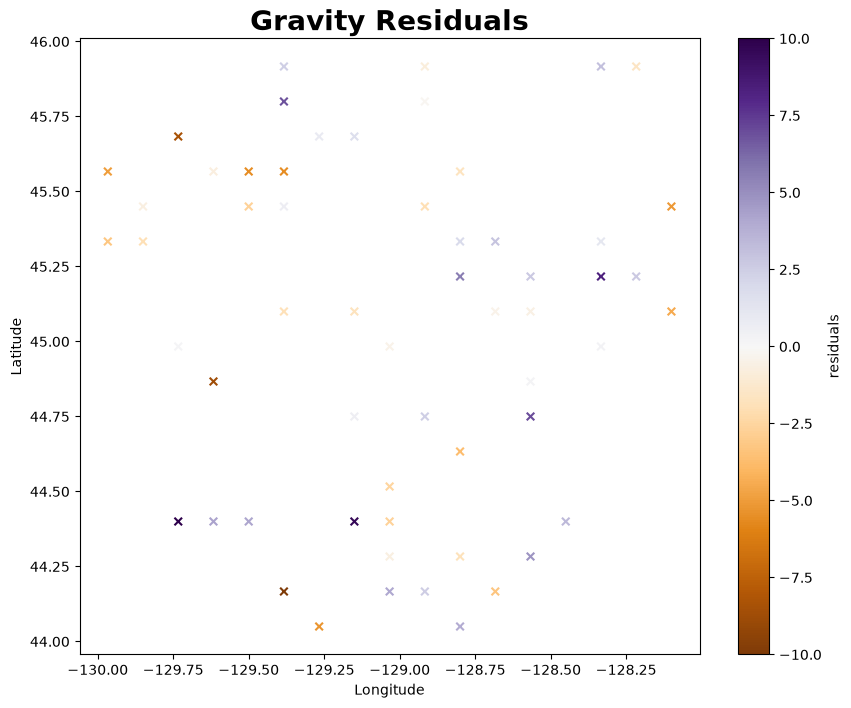

In [329]:
plt.figure(figsize=(10, 8))
plt.scatter(coords_test['long'], coords_test['lat'], c=residuals, cmap='PuOr',
            marker='x', s=30, vmin=-10, vmax=10)
plt.colorbar(label='residuals')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Gravity Residuals', fontdict={
    'fontsize':20,
    'fontweight':'bold'
})

plt.savefig('..\\figs\\grav\\xval\\aug17_res_grav.png', dpi=400)
plt.show()

## now we ... predict!

we start with predicting a different location...

In [330]:
de = pd.read_csv('..\\data\\test_filt_lola_grav_age_q_z_bath.csv')
de.head()

,long,lat,FA,age,q_ihfc,q_ps,q_stein,ps_z,stein_z,bathy
0,-129.96667,46.033334,19.550854,1.296681,140.618650,415.474231,447.871688,2898.551650,3213.704250,-1890.455038
1,-129.96667,46.150001,15.839446,1.102703,133.856960,450.537857,485.669472,2867.533910,3043.823552,-1929.020123
2,-129.96667,46.266668,-1.490359,1.061749,133.643964,459.144926,494.947695,2860.644169,3011.468264,-2132.082961
3,-129.96667,46.383334,-5.334891,1.257110,173.370653,421.962731,454.866142,2892.423140,3176.818422,-2550.002440
4,-129.96667,46.500001,-0.176673,1.452470,213.097342,392.560874,423.171615,2921.814682,3370.029661,-2534.481152


In [331]:
xe = de.drop(columns=['long', 'lat','q_ps','ps_z', 'stein_z', 'q_stein', 'FA'])
ye = de['ps_z']

In [332]:
xe.head()

,age,q_ihfc,bathy
0,1.296681,140.618650,-1890.455038
1,1.102703,133.856960,-1929.020123
2,1.061749,133.643964,-2132.082961
3,1.257110,173.370653,-2550.002440
4,1.452470,213.097342,-2534.481152


In [333]:
sp = 250
grid_long = np.linspace(de['long'].min(), de['long'].max(), sp)
grid_lat = np.linspace(de['lat'].min(), de['lat'].max(), sp)

In [334]:
long, lat = np.meshgrid(grid_long, grid_lat)

In [335]:
long.shape, lat.shape

((250, 250), (250, 250))

Nearest copies the value of the closest data point, keeping original values sharp but blocky. Linear blends adjacent points using a straight line or weighted average.

In [336]:
age_interp = griddata((de['long'], de['lat']), de['age'], (long, lat), method='linear')
hf_interp  = griddata((de['long'], de['lat']), de['q_ihfc'], (long, lat), method='linear')
bathy_interp = griddata((de['long'], de['lat']), de['bathy'], (long, lat), method='linear')

In [337]:
np.where(~np.isnan(age_interp))

(array([  0,   0,   0, ..., 249, 249, 249], shape=(62500,)),
 array([  0,   1,   2, ..., 247, 248, 249], shape=(62500,)))

In [338]:
hf_interp[130:135, 130:135], age_interp[130:135, 130:135], bathy_interp[130:135, 130:135]

(array([[270.30851704, 270.04994841, 269.79137978, 269.53281115,
         269.27424251],
        [274.88765058, 274.62908195, 274.37051332, 274.11194468,
         271.35461972],
        [279.46678412, 279.20821549, 278.94964686, 276.19232189,
         270.22231021],
        [284.04591766, 283.78734903, 281.03002406, 275.06001238,
         269.09000071],
        [288.6250512 , 285.86772623, 279.89771456, 273.92770288,
         267.9576912 ]]),
 array([[0.33691599, 0.35415015, 0.37138431, 0.38861847, 0.40585263],
        [0.33639895, 0.35363311, 0.37086727, 0.38810143, 0.40462796],
        [0.3358819 , 0.35311606, 0.37035022, 0.38687676, 0.40249349],
        [0.33536486, 0.35259902, 0.36912556, 0.38474229, 0.40035902],
        [0.33484782, 0.35137435, 0.36699109, 0.38260782, 0.39822455]]),
 array([[-2637.50652007, -2638.75389251, -2640.00126496, -2641.2486374 ,
         -2642.49600985],
        [-2635.53496875, -2636.7823412 , -2638.02971364, -2639.27708609,
         -2640.93155609],
   

In [339]:
age_interp.shape

(250, 250)

np.vstack stacks arrays as new rows

In [340]:
lola = np.vstack([age_interp.ravel(), hf_interp.ravel(), bathy_interp.ravel()]).T

In [341]:
lola.shape

(62500, 3)

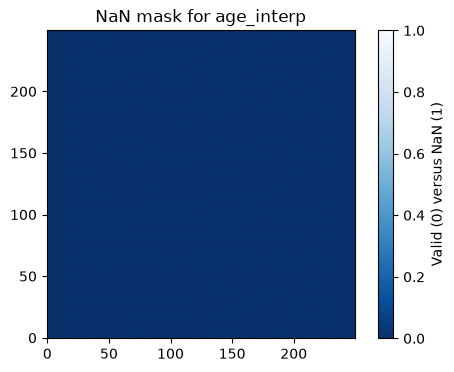

In [342]:
np.where(np.isnan(lola))

plt.figure(figsize=(6,4))
plt.imshow(np.isnan(age_interp), origin='lower', cmap='Blues_r', vmin=0, vmax=1)
plt.title('NaN mask for age_interp')
plt.colorbar(label='Valid (0) versus NaN (1)')
plt.show()

In [343]:
lola_pred = model.predict(lola)

In [344]:
lola_pred[180:184]

array([ 1.02875368,  1.02875368, -0.55585612, -0.55585612])

In [345]:
lola_pred = lola_pred.reshape(long.shape)

In [346]:
lola_pred.shape

(250, 250)

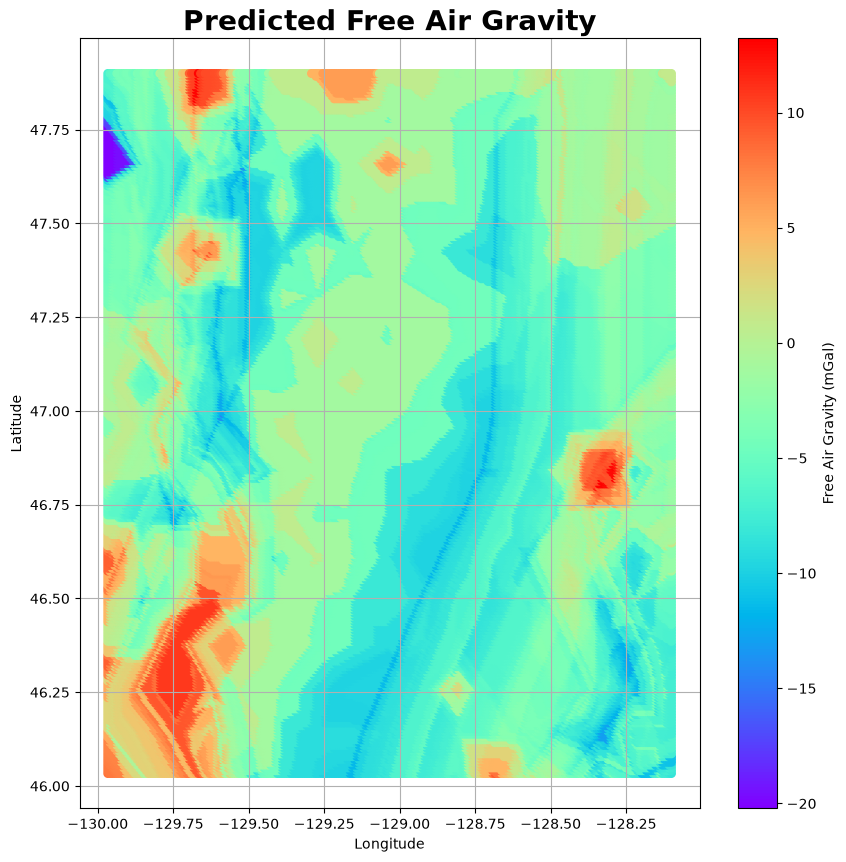

In [347]:
plt.figure(figsize=(10, 10))
plt.scatter(long, lat, c=lola_pred, cmap='rainbow', marker='o', s=30)
plt.colorbar(label='Free Air Gravity (mGal)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Predicted Free Air Gravity', fontdict={
    'fontsize':20,
    'fontweight':'bold'
})
plt.grid()

plt.savefig(f'..\\figs\\grav\\xval\\aug17_grav_pred_{sp}.png', dpi=400)
plt.show()

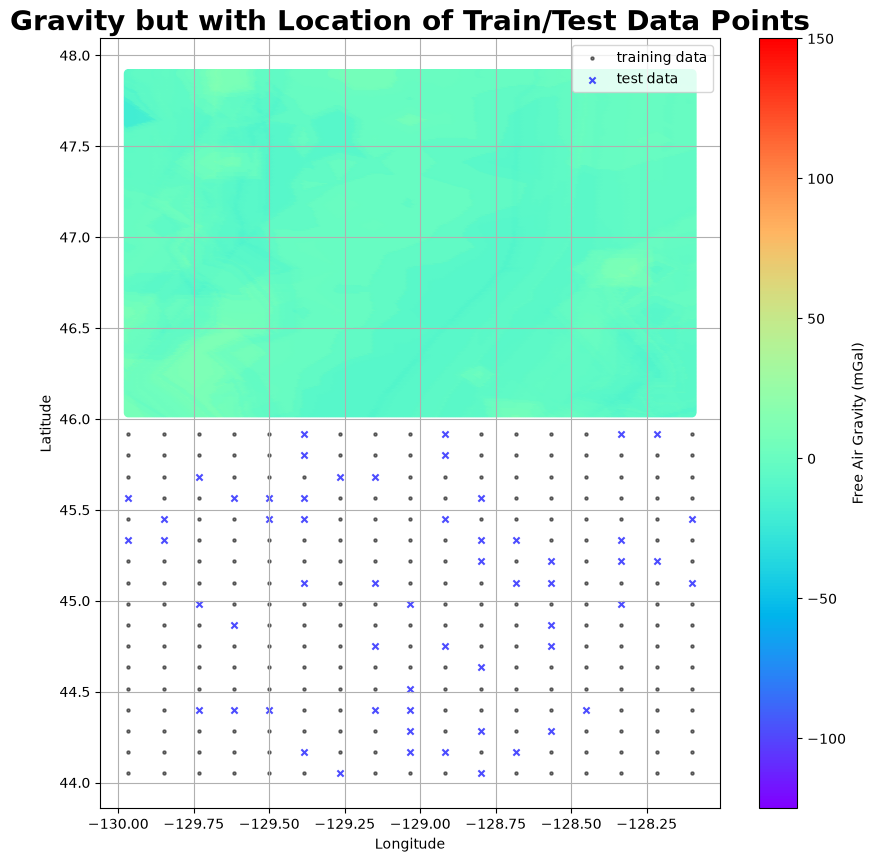

In [348]:
plt.figure(figsize=(10, 10))
plt.scatter(long, lat, c=lola_pred, cmap='rainbow', marker='o', s=30,
            vmin=-125, vmax=150)
plt.colorbar(label='Free Air Gravity (mGal)')
plt.scatter(coords_train['long'], coords_train['lat'], marker='o', color='black', s=5, label='training data', alpha=0.5)
plt.scatter(coords_test['long'], coords_test['lat'], marker='x', color='blue', s=20, label='test data', alpha=0.7)
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.title('Gravity but with Location of Train/Test Data Points', fontdict={
    'fontsize':20,
    'fontweight':'bold'
})
plt.legend(loc='upper right')
plt.grid()

plt.savefig(f'..\\figs\\grav\\xval\\aug17_grav_pnts_pred_{sp}.png', dpi=400)
plt.show()

In [167]:
pred_real = griddata((long.ravel(), lat.ravel()), lola_pred.ravel(), (de['long'].values, de['lat'].values), 
                method='linear')

valid = ~np.isnan(pred_real)

In [175]:
print(f'R^2: {r2_score(de['FA'].values[valid], pred_real[valid])}')
print(f'rmse: {model.best_score['valid_0']['rmse']}')

R^2: -6.0648562078723085
rmse: 21.314077550296286


In [180]:
y_pred_same_region = model.predict(x_test)
ye_pred_real = model.predict(de[x_train.columns])

with open('..\\created_data\\tests\\xval\\notes_aug16.txt', 'w') as f:
    f.write(f'the training data:\n{df[['age','q_ihfc','bathy']].describe()}\n')
    f.write(f'\nthe test data:\n{de[['age','q_ihfc','bathy']].describe()}\n')
    f.write(f'\nrmse: {model.best_score['valid_0']['rmse']}\n')
    f.write(f'same-region R^2: {r2_score(y_test, y_pred_same_region)}\n')
    f.write(f'new-region R^2: {r2_score(de['FA'], ye_pred_real)}\n')